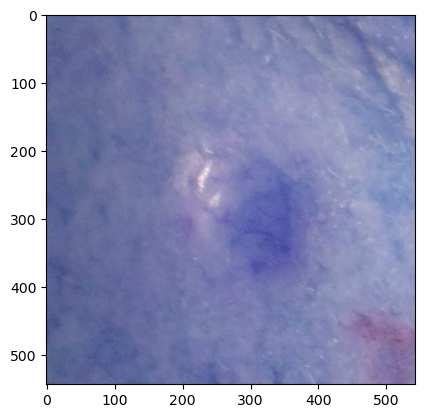

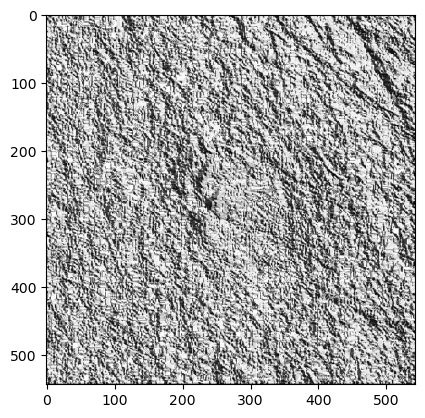

LBP Program is finished
[9.97657350e-03 5.51809121e-04 5.39621926e-03 4.06578377e-03
 6.36442422e-04 3.38533203e-05 3.68662658e-03 4.59389557e-03
 7.38340916e-03 4.70561153e-04 6.49983750e-04 7.41387715e-04
 4.89519012e-03 1.25257285e-04 1.98583577e-02 2.60535153e-02
 7.48158379e-04 4.06239844e-05 4.02854512e-04 4.13010508e-04
 4.06239844e-05 6.77066407e-06 6.77066407e-05 1.65881270e-04
 5.05091539e-03 5.11185137e-04 5.85662442e-04 1.15101289e-03
 6.01234969e-03 1.59110606e-04 2.38428935e-02 2.88464143e-02
 5.40298993e-03 3.69001192e-04 2.14968584e-03 7.95553028e-04
 3.92698516e-04 4.73946485e-05 7.10919727e-04 5.95818438e-04
 5.14570469e-04 2.03119922e-05 1.15101289e-04 2.36973242e-05
 5.55194453e-04 6.77066407e-06 1.22210486e-03 5.55194453e-04
 4.21473838e-03 4.36707832e-04 7.88782364e-04 3.24991875e-04
 9.47892969e-05 6.77066407e-06 2.84367891e-04 3.41918535e-04
 1.64933377e-02 1.56402340e-03 1.24580219e-03 1.36428881e-03
 1.83586556e-02 6.73681075e-04 3.26955368e-02 1.95333658e-02


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
    
def get_pixel(img, center, x, y):
    
    new_value = 0
    
    try:
        # If local neighbourhood pixel 
        # value is greater than or equal
        # to center pixel values then 
        # set it to 1
        if img[x][y] >= center:
            new_value = 1
            
    except:
        # Exception is required when 
        # neighbourhood value of a center
        # pixel value is null i.e. values
        # present at boundaries.
        pass
    
    return new_value
 
# Function for calculating LBP
def lbp_calculated_pixel(img, x, y):
 
    center = img[x][y]
 
    val_ar = []
    
    # top_left
    val_ar.append(get_pixel(img, center, x-1, y-1))
    
    # top
    val_ar.append(get_pixel(img, center, x-1, y))
    
    # top_right
    val_ar.append(get_pixel(img, center, x-1, y + 1))
    
    # right
    val_ar.append(get_pixel(img, center, x, y + 1))
    
    # bottom_right
    val_ar.append(get_pixel(img, center, x + 1, y + 1))
    
    # bottom
    val_ar.append(get_pixel(img, center, x + 1, y))
    
    # bottom_left
    val_ar.append(get_pixel(img, center, x + 1, y-1))
    
    # left
    val_ar.append(get_pixel(img, center, x, y-1))
     
    # Now, we need to convert binary
    # values to decimal
    power_val = [1, 2, 4, 8, 16, 32, 64, 128]
 
    val = 0
    
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
        
    return val
 
path = '../data/imgs/PAT_326_690_823.png'
img_bgr = cv2.imread(path)
 
height, width, _ = img_bgr.shape
 
# We need to convert RGB image 
# into gray one because gray 
# image has one channel only.
img_gray = cv2.cvtColor(img_bgr,
                        cv2.COLOR_BGR2GRAY)
 
# Create a numpy array as 
# the same height and width 
# of RGB image
img_lbp = np.zeros((height, width),
                   np.uint8)
 
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)

plt.imshow(img_bgr)
plt.show()
 
plt.imshow(img_lbp, cmap ="gray")
plt.show()
 
print("LBP Program is finished")

height, width = img_gray.shape
    
    # 1. Obliczanie macierzy LBP
img_lbp = np.zeros((height, width), np.uint8)
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)
    
    # 2. Obliczanie histogramu (to są Twoje cechy)
    # Wykorzystujemy 256 kubełków (dla wartości 0-255)
hist, _ = np.histogram(img_lbp.ravel(), bins=256, range=(0, 256))
    
    # 3. Normalizacja (opcjonalna, ale zalecana)
    # Dzięki temu cechy nie zależą od wielkości obrazka
hist = hist.astype("float")
hist /= (hist.sum() + 1e-7)

print(hist)

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
 
 
def fast_lbp_synchronized(img_bgr):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.int32)
    rows, cols = img_gray.shape
    img_lbp = np.zeros((rows, cols), dtype=np.uint8)


    offsets = [
        (-1, -1), ( -1, 0), (-1, 1), (0, 1), 
        ( 1,  1), (  1, 0), ( 1, -1), (0, -1)
    ]
    
    powers = [1, 2, 4, 8, 16, 32, 64, 128]


    for i in range(len(offsets)):
        dy, dx = offsets[i]
        pwr = powers[i]
        
        shifted = np.zeros_like(img_gray)
        
        r_start, r_end = max(0, dy), rows + min(0, dy)
        c_start, c_end = max(0, dx), cols + min(0, dx)
        
        img_r_start, img_r_end = max(0, -dy), rows + min(0, -dy)
        img_c_start, img_c_end = max(0, -dx), cols + min(0, -dx)
        
        compare = img_gray[img_r_start:img_r_end, img_c_start:img_c_end] >= img_gray[r_start:r_end, c_start:c_end]
        
        shifted[r_start:r_end, c_start:c_end] = compare * pwr
        img_lbp += shifted.astype(np.uint8)

    # Histogram
    hist, _ = np.histogram(img_lbp.ravel(), bins=256, range=(0, 256))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    
    return hist

In [12]:

img_org = cv2.imread(path)

print(hist)

print('---------------------------')
print(fast_lbp_synchronized(img_org))

[9.97657350e-03 5.51809121e-04 5.39621926e-03 4.06578377e-03
 6.36442422e-04 3.38533203e-05 3.68662658e-03 4.59389557e-03
 7.38340916e-03 4.70561153e-04 6.49983750e-04 7.41387715e-04
 4.89519012e-03 1.25257285e-04 1.98583577e-02 2.60535153e-02
 7.48158379e-04 4.06239844e-05 4.02854512e-04 4.13010508e-04
 4.06239844e-05 6.77066407e-06 6.77066407e-05 1.65881270e-04
 5.05091539e-03 5.11185137e-04 5.85662442e-04 1.15101289e-03
 6.01234969e-03 1.59110606e-04 2.38428935e-02 2.88464143e-02
 5.40298993e-03 3.69001192e-04 2.14968584e-03 7.95553028e-04
 3.92698516e-04 4.73946485e-05 7.10919727e-04 5.95818438e-04
 5.14570469e-04 2.03119922e-05 1.15101289e-04 2.36973242e-05
 5.55194453e-04 6.77066407e-06 1.22210486e-03 5.55194453e-04
 4.21473838e-03 4.36707832e-04 7.88782364e-04 3.24991875e-04
 9.47892969e-05 6.77066407e-06 2.84367891e-04 3.41918535e-04
 1.64933377e-02 1.56402340e-03 1.24580219e-03 1.36428881e-03
 1.83586556e-02 6.73681075e-04 3.26955368e-02 1.95333658e-02
 5.28111797e-04 3.046798